# In dit notebook wordt de kalibratie en validatie uitgevoerd

Hierin wordt gekeken naar de kwaliteit van de kalibratie tussen een jaarlijkse, twee-seizoensgebonden en vier-seizoensgebonden bias correcties. 

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
project_dir = Path("/home/niels/BEP-Niels")

results_dir = project_dir / "results"
figures_dir = project_dir / "figures"
data_dir = project_dir / "Data Lobith"

figures_dir.mkdir(exist_ok=True)

print("Projectmap:", project_dir)
print("Results map bestaat:", results_dir.exists())
print("Figures map bestaat:", figures_dir.exists())
print("Data map bestaat:", data_dir.exists())

Projectmap: /home/niels/BEP-Niels
Results map bestaat: True
Figures map bestaat: True
Data map bestaat: True


In [3]:
# Deze notebook voert de wflow-run niet opnieuw uit.
# De gebruikte modeloutput is eerder opgeslagen als CSV.
#
# Gebruikte modelrun:
# calib10_long_1986_2019
#
# Gebruikte modelperiode:
# 1986-01-01 t/m 2019-12-31
#
# Analyseperiode:
# 1987-01-01 t/m 2019-12-31
#
# Kalibratieperiode:
# 1987-01-01 t/m 2003-12-31
#
# Validatieperiode:
# 2004-01-01 t/m 2019-12-31
#
# Calib10-instellingen:
# PET forcing x 0.90
# CanopyGapFraction.tbl x 1.25
# N_River.tbl x 2.00
# N.tbl x 1.25

In [4]:
analysis_start = "1987-01-01"
analysis_end = "2019-12-31"

cal_start = "1987-01-01"
cal_end = "2003-12-31"

val_start = "2004-01-01"
val_end = "2019-12-31"

val1_start = "2004-01-01"
val1_end = "2010-12-31"

val2_start = "2011-01-01"
val2_end = "2019-12-31"

threshold_1600 = 1600
threshold_1020 = 1020

print("Analyse:", analysis_start, "t/m", analysis_end)
print("Kalibratie:", cal_start, "t/m", cal_end)
print("Validatie totaal:", val_start, "t/m", val_end)
print("Validatie 1:", val1_start, "t/m", val1_end)
print("Validatie 2:", val2_start, "t/m", val2_end)

Analyse: 1987-01-01 t/m 2019-12-31
Kalibratie: 1987-01-01 t/m 2003-12-31
Validatie totaal: 2004-01-01 t/m 2019-12-31
Validatie 1: 2004-01-01 t/m 2010-12-31
Validatie 2: 2011-01-01 t/m 2019-12-31


In [5]:
grdc_file = data_dir / "data grdc" / "6435060_Q_Day.Cmd.txt"

print("GRDC bestand bestaat:", grdc_file.exists())
print(grdc_file)

GRDC bestand bestaat: True
/home/niels/BEP-Niels/Data Lobith/data grdc/6435060_Q_Day.Cmd.txt


In [6]:
grdc_raw = pd.read_csv(
    grdc_file,
    sep=";",
    comment="#",
    skipinitialspace=True,
    na_values=-999.000,
    encoding="latin1"
)

grdc_raw.columns = grdc_raw.columns.str.strip()

print("Kolommen:")
print(grdc_raw.columns)

grdc_raw.head()

Kolommen:
Index(['YYYY-MM-DD', 'hh:mm', 'Value'], dtype='object')


,YYYY-MM-DD,hh:mm,Value
0,1901-01-01,--:--,2035.0
1,1901-01-02,--:--,2270.0
2,1901-01-03,--:--,2445.0
3,1901-01-04,--:--,2325.0
4,1901-01-05,--:--,2175.0


In [7]:
grdc = grdc_raw.rename(columns={
    "YYYY-MM-DD": "date",
    "Value": "Q_grdc_m3s"
})

grdc["date"] = pd.to_datetime(grdc["date"])
grdc["Q_grdc_m3s"] = pd.to_numeric(grdc["Q_grdc_m3s"], errors="coerce")

grdc = grdc[["date", "Q_grdc_m3s"]].copy()

grdc = grdc.dropna()
grdc = grdc[grdc["Q_grdc_m3s"] > 0]
grdc = grdc[grdc["Q_grdc_m3s"] < 20000]

grdc = grdc[
    (grdc["date"] >= analysis_start) &
    (grdc["date"] <= analysis_end)
].copy()

print("Start GRDC:", grdc["date"].min())
print("Einde GRDC:", grdc["date"].max())
print("Aantal dagen:", len(grdc))

grdc.head()

Start GRDC: 1987-01-01 00:00:00
Einde GRDC: 2019-12-31 00:00:00
Aantal dagen: 12053


,date,Q_grdc_m3s
31411,1987-01-01,4865.0
31412,1987-01-02,5756.0
31413,1987-01-03,6160.0
31414,1987-01-04,6973.0
31415,1987-01-05,7579.0


In [8]:
model_file = results_dir / "calib10_long_1986_2019_lobith_daily.csv"

print("Modelbestand bestaat:", model_file.exists())
print(model_file)

Modelbestand bestaat: True
/home/niels/BEP-Niels/results/calib10_long_1986_2019_lobith_daily.csv


In [9]:
model = pd.read_csv(model_file)

model["date"] = pd.to_datetime(model["date"])

print("Kolommen:")
print(model.columns)

print("Start model:", model["date"].min())
print("Einde model:", model["date"].max())
print("Aantal dagen:", len(model))

model.head()

Kolommen:
Index(['date', 'Q_model_m3s'], dtype='object')
Start model: 1987-01-01 00:00:00
Einde model: 2019-12-31 00:00:00
Aantal dagen: 12053


,date,Q_model_m3s
0,1987-01-01,12101.763672
1,1987-01-02,13396.190430
2,1987-01-03,14481.406250
3,1987-01-04,14916.130859
4,1987-01-05,14704.667969


In [10]:
if "Q_model_raw_m3s" not in model.columns:
    model = model.rename(columns={
        "Q_model_m3s": "Q_model_raw_m3s"
    })

model = model[["date", "Q_model_raw_m3s"]].copy()

model.head()

,date,Q_model_raw_m3s
0,1987-01-01,12101.763672
1,1987-01-02,13396.190430
2,1987-01-03,14481.406250
3,1987-01-04,14916.130859
4,1987-01-05,14704.667969


In [11]:
comparison = pd.merge(
    grdc,
    model,
    on="date",
    how="inner"
)

comparison = comparison[
    (comparison["date"] >= analysis_start) &
    (comparison["date"] <= analysis_end)
].copy()

print("Start comparison:", comparison["date"].min())
print("Einde comparison:", comparison["date"].max())
print("Aantal dagen:", len(comparison))

comparison.head()

Start comparison: 1987-01-01 00:00:00
Einde comparison: 2019-12-31 00:00:00
Aantal dagen: 12053


,date,Q_grdc_m3s,Q_model_raw_m3s
0,1987-01-01,4865.0,12101.763672
1,1987-01-02,5756.0,13396.190430
2,1987-01-03,6160.0,14481.406250
3,1987-01-04,6973.0,14916.130859
4,1987-01-05,7579.0,14704.667969


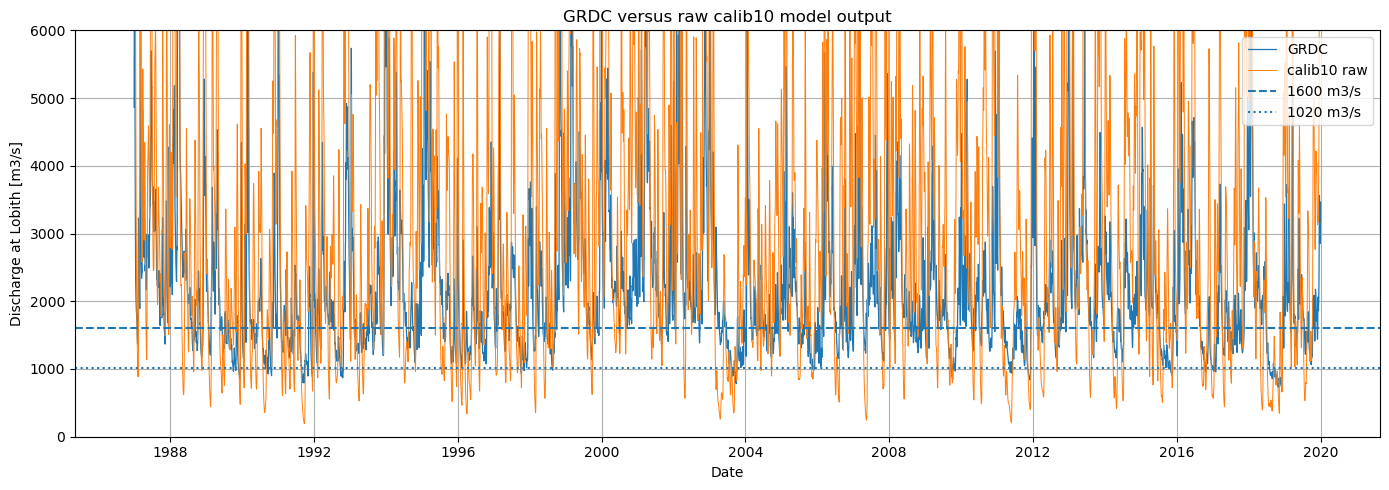

In [12]:
plt.figure(figsize=(14, 5))

plt.plot(
    comparison["date"],
    comparison["Q_grdc_m3s"],
    label="GRDC",
    linewidth=0.9
)

plt.plot(
    comparison["date"],
    comparison["Q_model_raw_m3s"],
    label="calib10 raw",
    linewidth=0.7
)

plt.axhline(threshold_1600, linestyle="--", label="1600 m3/s")
plt.axhline(threshold_1020, linestyle=":", label="1020 m3/s")

plt.ylim(0, 6000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m3/s]")
plt.title("GRDC versus raw calib10 model output")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
def calculate_scores(obs, sim):
    data = pd.DataFrame({
        "obs": obs,
        "sim": sim
    }).dropna()
    
    obs = data["obs"]
    sim = data["sim"]
    
    bias = (sim - obs).mean()
    rmse = np.sqrt(((sim - obs) ** 2).mean())
    
    log_obs = np.log(obs.clip(lower=1))
    log_sim = np.log(sim.clip(lower=1))
    
    log_nse = 1 - ((log_sim - log_obs) ** 2).sum() / ((log_obs - log_obs.mean()) ** 2).sum()
    
    diff_1600 = (sim < threshold_1600).sum() - (obs < threshold_1600).sum()
    diff_1020 = (sim < threshold_1020).sum() - (obs < threshold_1020).sum()
    
    diff_p10 = sim.quantile(0.10) - obs.quantile(0.10)
    diff_p17 = sim.quantile(0.17) - obs.quantile(0.17)
    
    return {
        "bias": round(bias, 2),
        "rmse": round(rmse, 2),
        "log_nse": round(log_nse, 2),
        "diff_days_below_1600": diff_1600,
        "diff_days_below_1020": diff_1020,
        "diff_p10": round(diff_p10, 2),
        "diff_p17": round(diff_p17, 2),
        "n_days": len(data)
    }

In [14]:
quantiles = np.linspace(0, 1, 101)

cal_fit = comparison[
    (comparison["date"] >= cal_start) &
    (comparison["date"] <= cal_end)
].copy()

obs_cal = cal_fit["Q_grdc_m3s"].dropna().values
sim_cal = cal_fit["Q_model_raw_m3s"].dropna().values

grdc_quantiles = np.quantile(obs_cal, quantiles)
model_quantiles = np.quantile(sim_cal, quantiles)

comparison["Q_model_annual_fdc_m3s"] = np.interp(
    comparison["Q_model_raw_m3s"],
    model_quantiles,
    grdc_quantiles
)

annual_fdc_correction = pd.DataFrame({
    "quantile": quantiles,
    "grdc": grdc_quantiles,
    "model": model_quantiles
})

comparison[[
    "date",
    "Q_grdc_m3s",
    "Q_model_raw_m3s",
    "Q_model_annual_fdc_m3s"
]].head()

,date,Q_grdc_m3s,Q_model_raw_m3s,Q_model_annual_fdc_m3s
0,1987-01-01,4865.0,12101.763672,6976.499195
1,1987-01-02,5756.0,13396.190430,7725.032013
2,1987-01-03,6160.0,14481.406250,8267.416049
3,1987-01-04,6973.0,14916.130859,8484.688672
4,1987-01-05,7579.0,14704.667969,8379.000850


In [15]:
comparison["month"] = comparison["date"].dt.month

comparison["two_season"] = "jan_jun"

comparison.loc[
    comparison["month"].isin([7, 8, 9, 10, 11, 12]),
    "two_season"
] = "jul_dec"

comparison["two_season"].value_counts()

two_season
jul_dec    6072
jan_jun    5981
Name: count, dtype: int64

In [16]:
two_season_corrections = {}

cal_fit = comparison[
    (comparison["date"] >= cal_start) &
    (comparison["date"] <= cal_end)
].copy()

for season in ["jan_jun", "jul_dec"]:
    
    data_season = cal_fit[
        cal_fit["two_season"] == season
    ].copy()
    
    obs = data_season["Q_grdc_m3s"].dropna().values
    sim = data_season["Q_model_raw_m3s"].dropna().values
    
    grdc_q = np.quantile(obs, quantiles)
    model_q = np.quantile(sim, quantiles)
    
    two_season_corrections[season] = {
        "grdc_q": grdc_q,
        "model_q": model_q
    }
    
    print(season, "aantal dagen:", len(data_season))

jan_jun aantal dagen: 3081
jul_dec aantal dagen: 3128


In [17]:
comparison["Q_model_two_season_fdc_m3s"] = np.nan

for season in ["jan_jun", "jul_dec"]:
    
    mask = comparison["two_season"] == season
    
    model_q = two_season_corrections[season]["model_q"]
    grdc_q = two_season_corrections[season]["grdc_q"]
    
    comparison.loc[mask, "Q_model_two_season_fdc_m3s"] = np.interp(
        comparison.loc[mask, "Q_model_raw_m3s"],
        model_q,
        grdc_q
    )

comparison[[
    "date",
    "two_season",
    "Q_model_raw_m3s",
    "Q_model_two_season_fdc_m3s"
]].head()

,date,two_season,Q_model_raw_m3s,Q_model_two_season_fdc_m3s
0,1987-01-01,jan_jun,12101.763672,7302.245563
1,1987-01-02,jan_jun,13396.190430,8260.342483
2,1987-01-03,jan_jun,14481.406250,9138.001682
3,1987-01-04,jan_jun,14916.130859,9489.581566
4,1987-01-05,jan_jun,14704.667969,9318.562725


In [18]:
comparison["four_season"] = "unknown"

comparison.loc[comparison["month"].isin([12, 1, 2]), "four_season"] = "winter"
comparison.loc[comparison["month"].isin([3, 4, 5]), "four_season"] = "lente"
comparison.loc[comparison["month"].isin([6, 7, 8]), "four_season"] = "zomer"
comparison.loc[comparison["month"].isin([9, 10, 11]), "four_season"] = "herfst"

comparison["four_season"].value_counts()

four_season
lente     3036
zomer     3036
herfst    3003
winter    2978
Name: count, dtype: int64

In [19]:
four_season_corrections = {}

cal_fit = comparison[
    (comparison["date"] >= cal_start) &
    (comparison["date"] <= cal_end)
].copy()

for season in ["winter", "lente", "zomer", "herfst"]:
    
    data_season = cal_fit[
        cal_fit["four_season"] == season
    ].copy()
    
    obs = data_season["Q_grdc_m3s"].dropna().values
    sim = data_season["Q_model_raw_m3s"].dropna().values
    
    grdc_q = np.quantile(obs, quantiles)
    model_q = np.quantile(sim, quantiles)
    
    four_season_corrections[season] = {
        "grdc_q": grdc_q,
        "model_q": model_q
    }
    
    print(season, "aantal dagen:", len(data_season))

winter aantal dagen: 1534
lente aantal dagen: 1564
zomer aantal dagen: 1564
herfst aantal dagen: 1547


In [20]:
comparison["Q_model_four_season_fdc_m3s"] = np.nan

for season in ["winter", "lente", "zomer", "herfst"]:
    
    mask = comparison["four_season"] == season
    
    model_q = four_season_corrections[season]["model_q"]
    grdc_q = four_season_corrections[season]["grdc_q"]
    
    comparison.loc[mask, "Q_model_four_season_fdc_m3s"] = np.interp(
        comparison.loc[mask, "Q_model_raw_m3s"],
        model_q,
        grdc_q
    )

comparison[[
    "date",
    "four_season",
    "Q_model_raw_m3s",
    "Q_model_four_season_fdc_m3s"
]].head()

,date,four_season,Q_model_raw_m3s,Q_model_four_season_fdc_m3s
0,1987-01-01,winter,12101.763672,6644.466539
1,1987-01-02,winter,13396.190430,7565.702692
2,1987-01-03,winter,14481.406250,8498.884130
3,1987-01-04,winter,14916.130859,8702.814537
4,1987-01-05,winter,14704.667969,8603.906462


In [21]:
cal_data = comparison[
    (comparison["date"] >= cal_start) &
    (comparison["date"] <= cal_end)
].copy()

val_data = comparison[
    (comparison["date"] >= val_start) &
    (comparison["date"] <= val_end)
].copy()

val1_data = comparison[
    (comparison["date"] >= val1_start) &
    (comparison["date"] <= val1_end)
].copy()

val2_data = comparison[
    (comparison["date"] >= val2_start) &
    (comparison["date"] <= val2_end)
].copy()

print("Kalibratie:", cal_data["date"].min(), "t/m", cal_data["date"].max(), "-", len(cal_data), "dagen")
print("Validatie totaal:", val_data["date"].min(), "t/m", val_data["date"].max(), "-", len(val_data), "dagen")
print("Validatie 1:", val1_data["date"].min(), "t/m", val1_data["date"].max(), "-", len(val1_data), "dagen")
print("Validatie 2:", val2_data["date"].min(), "t/m", val2_data["date"].max(), "-", len(val2_data), "dagen")

Kalibratie: 1987-01-01 00:00:00 t/m 2003-12-31 00:00:00 - 6209 dagen
Validatie totaal: 2004-01-01 00:00:00 t/m 2019-12-31 00:00:00 - 5844 dagen
Validatie 1: 2004-01-01 00:00:00 t/m 2010-12-31 00:00:00 - 2557 dagen
Validatie 2: 2011-01-01 00:00:00 t/m 2019-12-31 00:00:00 - 3287 dagen


In [22]:
def make_score_rows(data, period_name):
    
    rows = []
    
    model_versions = {
        "calib10_raw": "Q_model_raw_m3s",
        "annual_fdc": "Q_model_annual_fdc_m3s",
        "two_season_fdc": "Q_model_two_season_fdc_m3s",
        "four_season_fdc": "Q_model_four_season_fdc_m3s"
    }
    
    for run_name, col in model_versions.items():
        
        scores = calculate_scores(
            data["Q_grdc_m3s"],
            data[col]
        )
        
        scores["period"] = period_name
        scores["run"] = run_name
        
        rows.append(scores)
    
    return rows

In [23]:
score_rows = []

score_rows += make_score_rows(cal_data, "calibration_1987_2003")
score_rows += make_score_rows(val_data, "validation_2004_2019")
score_rows += make_score_rows(val1_data, "validation_2004_2010")
score_rows += make_score_rows(val2_data, "validation_2011_2019")

score_table = pd.DataFrame(score_rows)

score_table = score_table[
    [
        "period",
        "run",
        "bias",
        "rmse",
        "log_nse",
        "diff_days_below_1600",
        "diff_days_below_1020",
        "diff_p10",
        "diff_p17",
        "n_days"
    ]
]

score_table

,period,run,bias,rmse,log_nse,diff_days_below_1600,diff_days_below_1020,diff_p10,diff_p17,n_days
0,calibration_1987_2003,calib10_raw,1149.77,2089.22,-0.60,-300,572,-293.09,-125.60,6209
1,calibration_1987_2003,annual_fdc,0.68,686.27,0.61,9,-3,-0.00,0.07,6209
2,calibration_1987_2003,two_season_fdc,1.81,585.60,0.71,7,4,3.21,4.02,6209
3,calibration_1987_2003,four_season_fdc,0.29,575.73,0.73,6,3,2.28,1.75,6209
4,validation_2004_2019,calib10_raw,1130.10,1943.32,-1.22,-434,533,-326.08,-117.06,5844
5,validation_2004_2019,annual_fdc,117.84,616.01,0.53,-126,-22,-5.53,20.86,5844
6,validation_2004_2019,two_season_fdc,124.49,547.11,0.65,-167,55,-18.33,5.13,5844
7,validation_2004_2019,four_season_fdc,125.91,557.78,0.66,-131,43,-31.50,-5.01,5844
8,validation_2004_2010,calib10_raw,1252.58,1946.43,-1.94,-308,188,-167.14,43.58,2557
9,validation_2004_2010,annual_fdc,163.81,607.60,0.39,-159,13,22.41,38.49,2557


In [24]:
lowflow_score_table = score_table[
    [
        "period",
        "run",
        "diff_days_below_1020",
        "diff_days_below_1600",
        "diff_p10",
        "diff_p17",
        "rmse",
        "log_nse"
    ]
].copy()

lowflow_score_table

,period,run,diff_days_below_1020,diff_days_below_1600,diff_p10,diff_p17,rmse,log_nse
0,calibration_1987_2003,calib10_raw,572,-300,-293.09,-125.60,2089.22,-0.60
1,calibration_1987_2003,annual_fdc,-3,9,-0.00,0.07,686.27,0.61
2,calibration_1987_2003,two_season_fdc,4,7,3.21,4.02,585.60,0.71
3,calibration_1987_2003,four_season_fdc,3,6,2.28,1.75,575.73,0.73
4,validation_2004_2019,calib10_raw,533,-434,-326.08,-117.06,1943.32,-1.22
5,validation_2004_2019,annual_fdc,-22,-126,-5.53,20.86,616.01,0.53
6,validation_2004_2019,two_season_fdc,55,-167,-18.33,5.13,547.11,0.65
7,validation_2004_2019,four_season_fdc,43,-131,-31.50,-5.01,557.78,0.66
8,validation_2004_2010,calib10_raw,188,-308,-167.14,43.58,1946.43,-1.94
9,validation_2004_2010,annual_fdc,13,-159,22.41,38.49,607.60,0.39


In [25]:
def plot_fdc(data, title):
    
    plt.figure(figsize=(9, 5))
    
    columns = {
        "GRDC": "Q_grdc_m3s",
        "raw": "Q_model_raw_m3s",
        "two-season FDC": "Q_model_two_season_fdc_m3s",
        "four-season FDC": "Q_model_four_season_fdc_m3s"
    }
    
    for label, col in columns.items():
        
        q = data[col].dropna().sort_values(ascending=False).values
        p = np.arange(1, len(q) + 1) / (len(q) + 1) * 100
        
        plt.plot(p, q, label=label)
    
    plt.axhline(threshold_1600, linestyle="--", label="1600 m3/s")
    plt.axhline(threshold_1020, linestyle=":", label="1020 m3/s")
    
    plt.xlabel("Exceedance probability [%]")
    plt.ylabel("Discharge at Lobith [m3/s]")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

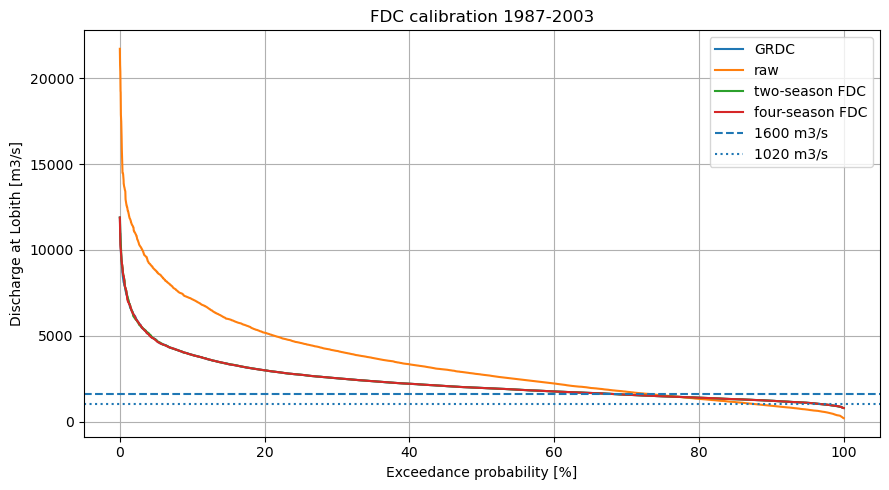

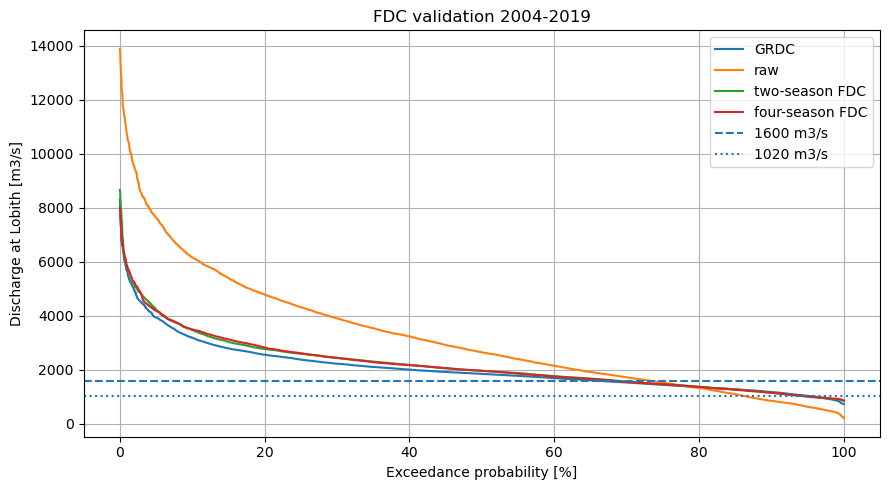

In [26]:
plot_fdc(
    cal_data,
    "FDC calibration 1987-2003"
)

plot_fdc(
    val_data,
    "FDC validation 2004-2019"
)

In [27]:
def plot_discharge_timeseries(data, title, ylim_max=6000):
    
    plt.figure(figsize=(14, 5))
    
    plt.plot(
        data["date"],
        data["Q_grdc_m3s"],
        label="GRDC",
        linewidth=1.0
    )
    
    # plt.plot(
    #     data["date"],
    #     data["Q_model_raw_m3s"],
    #     label="raw",
    #     linewidth=0.6
    # )
    
    plt.plot(
        data["date"],
        data["Q_model_two_season_fdc_m3s"],
        label="two-season FDC",
        linewidth=0.9
    )
    
    plt.plot(
        data["date"],
        data["Q_model_four_season_fdc_m3s"],
        label="four-season FDC",
        linewidth=0.9
    )
    
    plt.axhline(threshold_1600, linestyle="--", label="1600 m3/s")
    plt.axhline(threshold_1020, linestyle=":", label="1020 m3/s")
    
    plt.ylim(0, ylim_max)
    
    plt.xlabel("Date")
    plt.ylabel("Discharge at Lobith [m3/s]")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

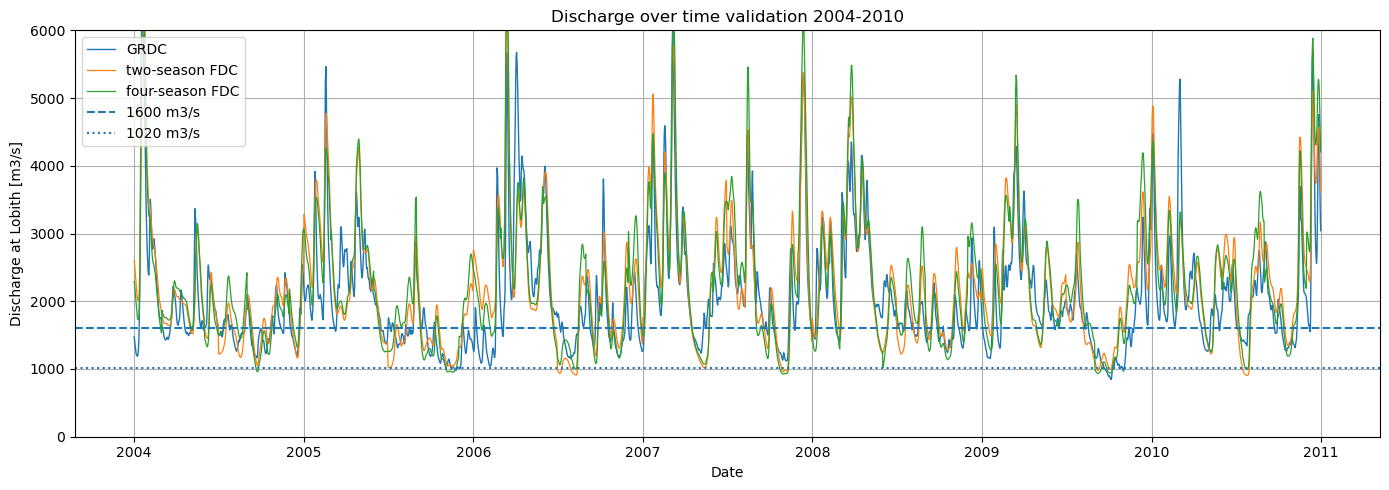

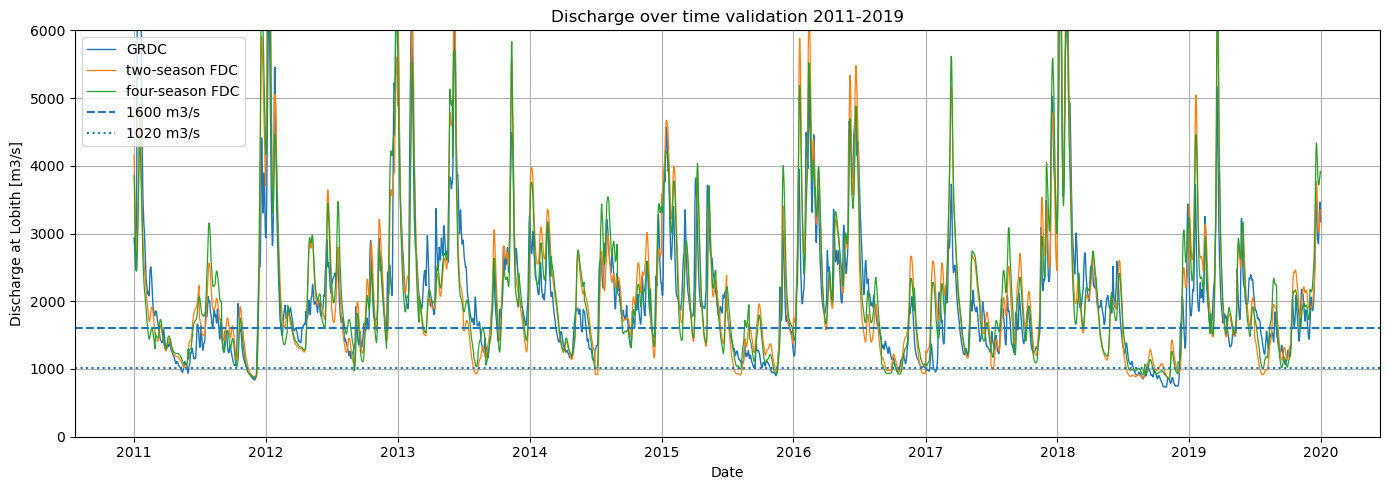

In [28]:
plot_discharge_timeseries(
    val1_data,
    "Discharge over time validation 2004-2010"
)

plot_discharge_timeseries(
    val2_data,
    "Discharge over time validation 2011-2019"
)